In [16]:
def find_linear_relationship (subset, variable1):
    x = subset[variable1]
    y = subset["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    print(" Simple:", f"{r2_simple:.2f}", p_value)  
    
def find_linear_relationship_with_max_precip (subset, variable1, variable2=None):
    model = smf.ols( f"Q('10cm_area') ~ max_precip + {variable1}",data=subset).fit()
    if variable2!=None:
        model = smf.ols( f"Q('10cm_area') ~ max_precip  + {variable1} + {variable2}",data=subset).fit()

    r2 = model.rsquared
    p = model.pvalues[variable1]
    if p <0.005:
        p = '<0.05'
    else:
        p = f"= {round(p, 2)}"
        
    if variable2==None:        
        print(f" Only {variable1}:", f"{r2:.2f}, p", p)    
    else:
        print(f" {variable1} + {variable2} :", f"{r2:.2f}, p", p)    
        
        
def add_region_geometries(df):
    regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
    regions_df = gpd.read_file(regions_shp)
    regions_df["region_geometry"] = regions_df.geometry

    catchments_df = CATCHMENTS
    catchments_df["catchment_geometry"] = catchments_df.geometry

    # Event points
    df = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df["x_coord"], df["y_coord"]), crs=regions_df.crs)

    # Remove old sjoin columns if this dataframe has been joined before
    df = df.drop(columns=["index_right", "geo_region", "region_geometry", "HA_NAME", "catchment_geometry"], errors="ignore")

    # Join regions
    df = gpd.sjoin(df, regions_df[["geo_region", "region_geometry", "geometry"]], how="left", predicate="within")

    # Drop index_right before the next sjoin, or geopandas will error on the clash
    df = df.drop(columns=["index_right"], errors="ignore")

    # Join catchments
    df = gpd.sjoin(df, catchments_df[["HA_NAME", "catchment_geometry", "geometry"]], how="left", predicate="within")

    df = df.drop(columns=["index_right"], errors="ignore")        
    
    return df

In [10]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.stats import zscore, linregress
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENTS

In [ ]:
region_order = ["North Scotland","East Scotland","West Scotland","North West England","North East England",
                "Yorkshire and Humber","West Midlands","East Midlands","East of England","Wales",
                "South West England","South East England","London"]

### Get v4 data

In [32]:
catchment_num = '105'

In [33]:
fp =  f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/all_events_added_soilvars_withbias.csv"
v4 = pd.read_csv(fp)
v4.rename(columns={'hc_at_peak.1':"new_hc_at_peak"}, inplace=True)
v4 = v4[v4['max_precip']<130].copy()
v4 = v4[v4['ens']==1]
v4.reset_index(inplace=True, drop=True)
v4['sat_at_peak'] = v4['sat_at_peak_old']

### Get v5 data

In [35]:
fp =  f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v5/Catchment_{catchment_num}/all_events_added_soilvars.csv"
v5 = pd.read_csv(fp)
v5.rename(columns={'hc_at_peak':"new_hc_at_peak"}, inplace=True)
v5 = v5[v5['max_precip']<130].copy()
v5 = v5[v5['ens']==1]
v5.reset_index(inplace=True, drop=True)
v5['sat_at_peak'] = v4['sat_at_peak_new']

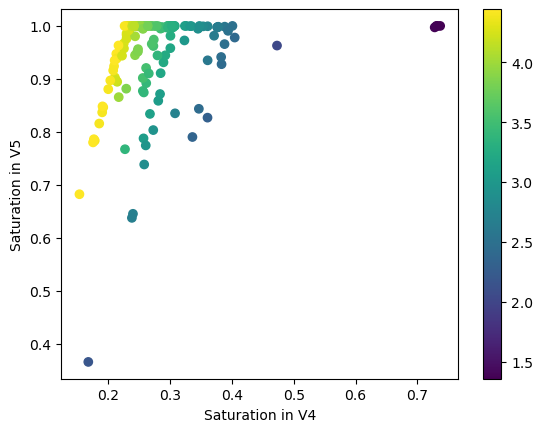

In [37]:
sc = plt.scatter(v4['sat_at_peak_old'], v4['sat_at_peak_new'], 
            c = v4['sat_at_peak_new'] / v4['sat_at_peak_old'],)
plt.xlabel('Saturation in V4')
plt.ylabel('Saturation in V5')
plt.colorbar(sc)
# fumax_at_peak, lu_at_peak, new_hc_at_peak are the same

In [51]:
# list(v4.columns)

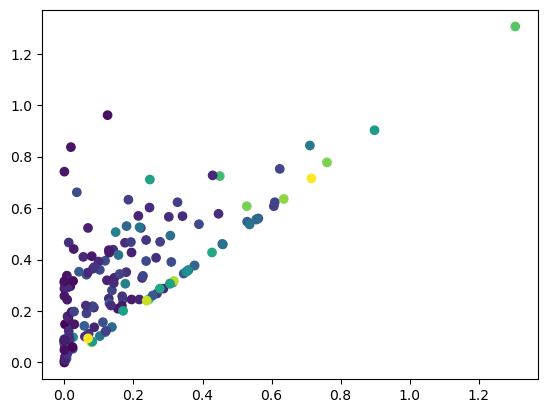

In [53]:
sc = plt.scatter(v4['10cm_area'], v5['10cm_area'], c = v4['total_acc'])

In [26]:
names = ['With incorrect soil moisture (V4)', "With correct soil moisture (v5)"]
for num, rainfall_df in enumerate([v4, v5]):

    subset = rainfall_df
    
    print(names[num])
    print("Relationship between 10cm area and max precip")
    # Simple regression: flood area ~ rainfall intensity
    find_linear_relationship(subset, "max_precip")
    print("Adding affect of one other variable")
    # ------------------------
    #find_linear_relationship_with_max_precip(subset, "se_max")    
    
    # ------------------------
    #find_linear_relationship_with_max_precip(subset, "se_min")  
    
    # ------------------------
    find_linear_relationship_with_max_precip(subset, "sat_at_peak")      
    
    # ------------------------
    #find_linear_relationship_with_max_precip(subset, "fu_mean_m")    
    
    # ------------------------
    find_linear_relationship_with_max_precip(subset, "lu_at_peak")    

    # ------------------------
    #find_linear_relationship_with_max_precip(subset, "fu_max_m")    
    
    # ------------------------    
    #find_linear_relationship_with_max_precip(subset, "fu_min_m")     
    
    # ------------------------
    find_linear_relationship_with_max_precip(subset, "fu_at_peak")        

    # ------------------------    
    find_linear_relationship_with_max_precip(subset, "new_hc_at_peak")    

    # ------------------------    
    find_linear_relationship_with_max_precip(subset, "fumax_at_peak") 
    
    # ------------------------
    #find_linear_relationship_with_max_precip(subset, "new_hc_at_peak", "fu_at_peak")
    
    print('--------------------')

With incorrect soil moisture (V4)
Relationship between 10cm area and max precip
 Simple: 0.22 <0.05
Adding affect of one other variable
 Only sat_at_peak: 0.27, p = 0.01
 Only lu_at_peak: 0.53, p <0.05
 Only fu_at_peak: 0.22, p = 0.68
 Only new_hc_at_peak: 0.47, p <0.05
 Only fumax_at_peak: 0.54, p <0.05
--------------------
With correct soil moisture (v5)
Relationship between 10cm area and max precip
 Simple: 0.18 <0.05
Adding affect of one other variable
 Only sat_at_peak: 0.22, p = 0.04
 Only lu_at_peak: 0.46, p <0.05
 Only fu_at_peak: 0.19, p = 0.51
 Only new_hc_at_peak: 0.39, p <0.05
 Only fumax_at_peak: 0.47, p <0.05
--------------------


Text(0, 0.5, '10 cm flood area')

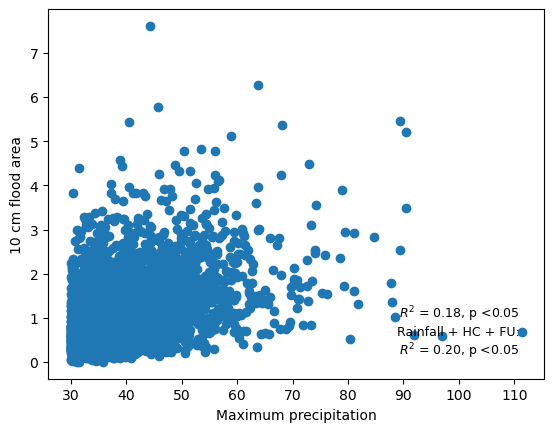

In [20]:
low_slope = rainfall_events_all_df[rainfall_events_all_df['peak_cell_slope_avg']<= 2]
medium_slope = rainfall_events_all_df[(rainfall_events_all_df['peak_cell_slope_avg']> 2) & 
                                      (rainfall_events_all_df['peak_cell_slope_avg']<15) ]
high_slope = rainfall_events_all_df[rainfall_events_all_df['peak_cell_slope_avg']> 15]

cell_with_most = low_slope
x = cell_with_most["max_precip"]
y = cell_with_most["10cm_area"]

fig,ax=plt.subplots()
ax.scatter(x, y)

# Simple regression: flood area ~ rainfall intensity
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r2_simple = r_value**2

p_value_text = "<0.05" if p_value < 0.05 else f"{p_value:.3f}"

# Multiple regression: flood area ~ rainfall intensity + HC + FU
model3 = smf.ols(
    "Q('10cm_area') ~ max_precip  + fu_at_peak",
    data=cell_with_most
).fit()

r2_model3 = model3.rsquared
p_model3 = model3.pvalues["fu_at_peak"]

p_model3_text = "<0.05" if p_model3 < 0.05 else f"{p_model3:.3f}"

# Text automatically positioned bottom-right
ax.text(
    0.95, 0.05,
    f"$R^2$ = {r2_simple:.2f}, p {p_value_text}\n"
    f"Rainfall + HC + FU:\n"
    f"$R^2$ = {r2_model3:.2f}, p {p_model3_text}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9)

ax.set_xlabel("Maximum precipitation")
ax.set_ylabel("10 cm flood area")